# Codes

## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## Linearised SWE Ver1

In [5]:
def make_grid(Lx, Ly, dx, dy):
    """ 
    Initialises our numerical simulation grid
    Lx: Length scale of Lake
    Ly: Width scale of Lake
    dx: Step size in length
    dy: Step size in width
    """

    nx = int(Lx / dx) + 1
    ny = int(Ly / dy) + 1 

    x = np.linspace(0, Lx, nx)
    y = np.linspace(0, Ly, ny)
    
    return x, y, dx, dy


def make_bathymetry(x, y, max_depth=10.0):
    """
    Generates a fixed bathymetry: 
    A channel with a trapezoidal cross-section in the y-direction 
    and a shoaling ramp at the far end in the x-direction.
    """
    X, Y = np.meshgrid(x, y, indexing="ij")
    
    Lx = x[-1]
    Ly = y[-1]
    
    # Deep water for the first 60% of the channel, then sloping up to 0.
    x_start_ramp = 0.6 * Lx 
    
    Z_long = np.where(X < x_start_ramp, 
                      -max_depth, 
                      -max_depth * (1 - (X - x_start_ramp) / (Lx - x_start_ramp)))
                      
    # Transverse Profile (Trapezoidal cross-section in the y-direction)
    # Sloping banks on the sides taking up 20% of the width each.
    bank_width = 0.2 * Ly 
    
    Y_scale = np.ones_like(Y)
    
    # Left bank slope
    Y_scale = np.where(Y < bank_width, Y / bank_width, Y_scale)
    # Right bank slope
    Y_scale = np.where(Y > Ly - bank_width, (Ly - Y) / bank_width, Y_scale)
    
    # Combine them to form the final bed surface
    z_bed = Z_long * Y_scale
    
    return z_bed

# def make_bathymetry(x, y, bed_fn):
#     """
#     Generates the bathymetry from the equation, the user would provide
#     x: array of length data points
#     y: array of width data points
#     bed_fn: equation of bed surface
#     """

#     X, Y = np.meshgrid(x,y, indexing = "ij") # Makes our 2D grid
#     z_bed = bed_fn(X, Y) # Pass bed function as a lambda func or whatever but make it mathematically correct rep of bathymetry

#     return z_bed

def plot_bathymetry(x, y, z_bed, water_level = 0):
    """
    Plots the surface in 3D space. This is very specific to our cuboidal case!
    x: array of length data points
    y: array of width data points
    z_bed: (here) the bottom surface of cuboid
    water_level: elevation of water surface in metres (e.g. -10 means 10 m below rim). Only cells where z_bed < water_level are shown as wet.
    """

    X, Y = np.meshgrid(x,y, indexing = "ij")
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    bed = ax.plot_surface(X, Y, z_bed, cmap='terrain', edgecolor='none')

    z_water = np.where(z_bed < water_level, water_level, np.nan)
    ax.plot_surface(X, Y, z_water, color='lightblue', alpha=0.6)

    ax.set_xlabel('length (x) (m)')
    ax.set_ylabel('width (y) (m)')
    ax.set_zlabel('depth (z) (m)')

    ax.set_title(f"Lake Bathymetry with water level = {water_level} m")

    fig.colorbar(bed, ax=ax, shrink=0.5, label="Bed elevation (m)")

    # Better viewing angle
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    plt.show()

    # # Four walls (each is a vertical surface from bed edge up to z=0)
    # # x = 0 wall
    # ax.plot_surface(np.zeros((len(y), 2)),
    #                 np.array([y, y]).T,
    #                 np.array([-z_bed[0, :], np.zeros(len(y))]).T,
    #                 color='grey')
    
    # # x = Lx wall
    # ax.plot_surface(np.full((len(y), 2), x[-1]),
    #                 np.array([y, y]).T,
    #                 np.array([-z_bed[-1, :], np.zeros(len(y))]).T,
    #                 color='grey')
    
    # # y = 0 wall
    # ax.plot_surface(np.array([x, x]).T,
    #                 np.zeros((len(x), 2)),
    #                 np.array([-z_bed[:, 0], np.zeros(len(x))]).T,
    #                 color='grey')
    
    # # y = Ly wall
    # ax.plot_surface(np.array([x, x]).T,
    #                 np.full((len(x), 2), y[-1]),
    #                 np.array([-z_bed[:, -1], np.zeros(len(x))]).T,
    #                 color='grey')
    

    # ax.set_xlabel('length (x) (m)')
    # ax.set_ylabel('width (y) (m)')
    # ax.set_zlabel('depth (z) (m)')
    # plt.show()

def fill_water(z_bed, water_level):
    """
    This fills water; isn't it obvious?
    z_bed: bed surface
    water_level: water level you want in the lake in metres
    """

    H = np.maximum(water_level - z_bed, 0)
    return H

def make_initial_condition(x, y, H, x0, y0, A, r):
    """
    This is a proxy for debris trigger. Right now I am just injecting it as a initial non zero surface elevation at that place. It is taken as gaussian as of now, future improvements would
    include a Ricker wavelet (mexican hat) (ig?)
    x: array of length data points
    y: array of width data points
    H: undisturbed water depth at each point
    x0: x coord of debris impact
    y0: y coord of debris impact
    A: Surface height at that place due to impact
    r: Spatial width of the wave bump
    """
    X, Y = np.meshgrid(x, y, indexing='ij')
    nx = len(x)
    ny = len(y)
    
    eta = A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * r**2)) # Change this to Ricker wavelet if you are intelligent enough
    eta = eta * (H > 0)   # zero out land cells
    
    u = np.zeros((nx-1, ny)) # velocity in x direction
    v = np.zeros((nx, ny-1)) # velocity in y direction
    
    return eta, u, v

def run_swe(x, y, dx, dy, H, z_bed, eta, u, v, T, mon_x, mon_y, g=9.8):
    """ 
    Solves the Linearised Shallow Water Equations!
    x: array of length data points
    y: array of width data points
    dx: Step size in length
    dy: Step size in width
    H: undisturbed water depth at each point
    z_bed: bed bathymetry
    eta: surface water displacement due to wave
    u: x direction velocity
    v: y direction velocity
    T: Total time of simulation
    g: gravitational acceleration
    mon_x: x coord of monitor location - where we want our wave height and every other stuff
    mon_y: y coord of monitor location - where we want our wave height and every other stuff
    """

    dt = 0.4 * min(dx, dy) / np.sqrt(g * H.max()) # CFL condition - 0.4 is just for safety
    # v = (gH)^0.5. But here H varies with x and y, so velocity should vary. Putting that into dt gives a weird result but we will see anyways

    n_steps = int(T / dt) # Number of time steps!

    # Choose the nearest cell coords for monitor location
    mi = np.argmin(np.abs(x - mon_x))
    mj = np.argmin(np.abs(y - mon_y))

    # This guy will have the monitor location wave displacement
    eta_mon = np.zeros(n_steps)

    snapshots = [] 

    # Interpolation of Hx and Hy. In staggered grid config, Hx and Hy are defined at middle of cells but to have a smooth profile we need to intrapolate stuff in between 
    Hx = 0.5 * (H[1:, :] + H[:-1, :])
    Hy = 0.5 * (H[:, 1:] + H[:, :-1])

    # Cells with zero water should have zero velocity
    u_mask = (H[:-1, :] > 0) & (H[1:, :] > 0)
    v_mask = (H[:, :-1] > 0) & (H[:, 1:] > 0)

    for step in range(n_steps):

        eta[1:-1,1:-1] -= (dt/dx) * (Hx[1:,1:-1]*u[1:,1:-1] - Hx[:-1,1:-1]*u[:-1,1:-1]) + (dt/dy) * (Hy[1:-1,1:]*v[1:-1,1:] - Hy[1:-1,:-1]*v[1:-1,:-1])

        u = u - (g*dt/dx) * (eta[1:,:] - eta[:-1,:])
        v = v - (g*dt/dy) * (eta[:,1:] - eta[:,:-1])
    
        # Reflective walls!
        u[0, :]  = 0
        u[-1, :] = 0
        v[:, 0]  = 0
        v[:, -1] = 0

        u *= u_mask
        v *= v_mask

        # Cells with zero stuff should have zero wave height
        eta[H == 0] = 0

        # Contains wave amp info at our monitor location
        eta_mon[step] = eta[mi, mj]

        # This is for GIF generation of whole lake. We take images every 10 time steps and do stuff with it
        if step % 10 == 0:
            snapshots.append(eta.copy())

    return eta_mon, snapshots

def plot_waves(x, y, snapshots, dt, snap_interval = 10, filename = "wave_sim.gif"):
    """
    Plots a top down view of the waves!
    x: array of length data points
    y: array of width data points
    snapshots: a list of eta taken after certain time intervals
    dt: time step
    snap_interval: time interval of "snapping" eta
    filename: what do you wanna save the gif as? Default is "wave_sim.gif"
    """

    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    initial_max = np.max(np.abs(snapshots[0]))
    
    # Set the limit to 2.5x the starting height to comfortably fit the shoaling
    v_limit = initial_max * 2.5 
    
    # Fallback just in case the initial max is somehow 0
    if v_limit == 0: 
        v_limit = 2.0

    pcm = ax.pcolormesh(x, y, snapshots[0].T, cmap='coolwarm', 
                        vmin=-v_limit, vmax=v_limit, shading='auto')
    plt.colorbar(pcm, ax=ax, label="Surface Elevation, eta (m)")


    def update(frame):
        pcm.set_array(snapshots[frame].T.ravel())
        ax.set_title(f"t = {frame * snap_interval * dt:.1f} s")
        return pcm,

    anim = animation.FuncAnimation(fig, update, frames=len(snapshots))
    anim.save(filename, writer="pillow", fps=20)
    plt.show()

def run_wave_simulation(Lx, Ly, dx, dy, max_depth, water_level, A, r, x0, y0, T, mon_x, mon_y, gif_filename):
    """
    
    Parameters:
    Lx, Ly: Lake dimensions (m)
    dx, dy: Grid resolution (m)
    max_depth: Maximum depth of the trapezoidal/ramp bathymetry (m)
    water_level: Elevation of the still water surface (m)
    A: Initial amplitude of the Gaussian wavelet (m) - Keep small for linear assumption!
    r: Spatial radius of the initial wave (m)
    x0, y0: Coordinates of the initial wave trigger (m)
    T: Total simulation time (s)
    mon_x, mon_y: Coordinates for the wave gauge monitor (m)
    gif_filename: Name of the output animation file
    """
    
    print("Initialising grid")
    x, y, dx, dy = make_grid(Lx, Ly, dx, dy)
    
    print("Generating bathymetry")
    z_bed = make_bathymetry(x, y, max_depth)
    
    plot_bathymetry(x, y, z_bed, water_level)
    
    print("Filling water")
    H = fill_water(z_bed, water_level)
    
    print(f"Triggering initial Gaussian wavelet (A={A}m) at x={x0}, y={y0}")
    eta, u, v = make_initial_condition(x, y, H, x0, y0, A, r)
    
    print("Running LSWEM")
    eta_mon, snapshots = run_swe(x, y, dx, dy, H, z_bed, eta, u, v, T, mon_x, mon_y)
    
    print("Simulation complete! Generating plots")
    
    # Calculate the actual dt used in the solver to pass to the plotting function
    g = 9.81
    dt = 0.4 * min(dx, dy) / np.sqrt(g * H.max())
    
    # Plot the top-down 2D wave animation
    plot_waves(x, y, snapshots, dt, snap_interval=10, filename=gif_filename)
    
    # Plot the time-series data at the monitor location
    time_array = np.linspace(0, T, len(eta_mon))
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(time_array, eta_mon, color='b', linewidth=1.5)
    ax.set_title(f"Wave Elevation at Monitor Location (x={mon_x}m, y={mon_y}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Surface Displacement, eta (m)")
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print("All done!")

# run_wave_simulation(Lx=100.0, Ly=20.0, max_depth=10.0, A=0.1, x0=20.0, mon_x=80.0, T=25.0)

# Use Cases:

Initialising grid
Generating bathymetry


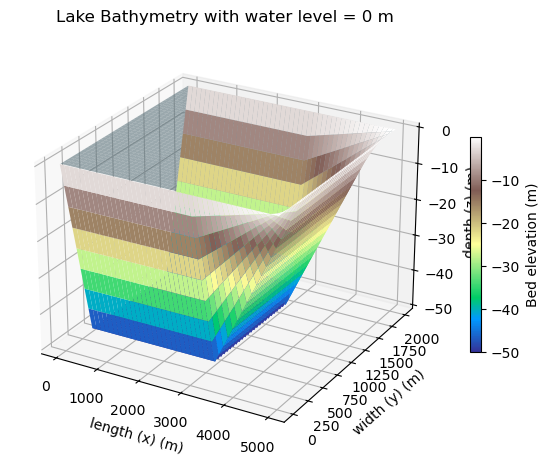

Filling water
Triggering initial Gaussian wavelet (A=1m) at x=4000, y=1000
Running LSWEM
Simulation complete! Generating plots


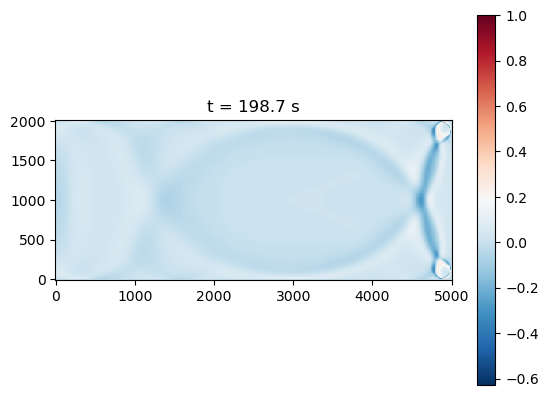

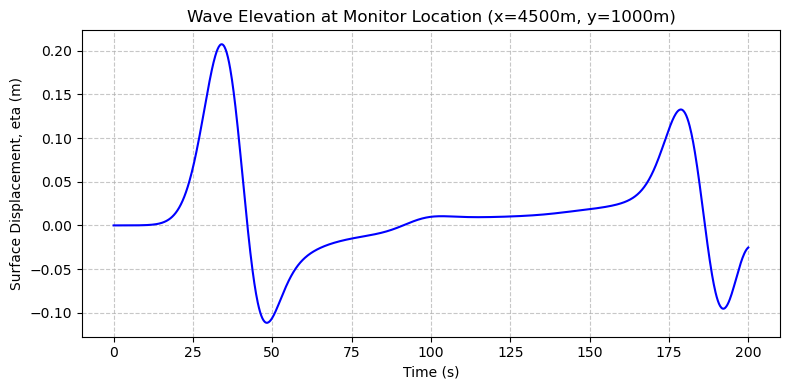

All done!


In [8]:
run_wave_simulation(Lx = 5000, Ly = 2000, dx = 10, dy = 10, max_depth = 50, water_level = 0, A = 1, r = 100, x0 = 4000, y0 = 1000, T = 200, mon_x = 4500, mon_y = 1000, gif_filename="lake_wave_sim.gif")

Running 1D Unidirectional Sine Wave Shoaling Test


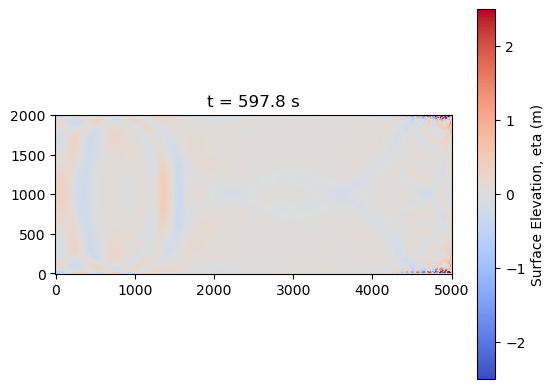

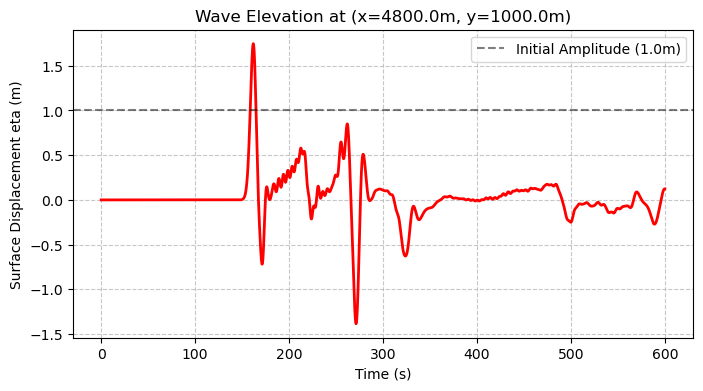

Test complete!


In [6]:
# 1D Unidirectional Sine Wave to Isolate Shoaling

def make_sine_wave(x, y, H, x0, A, width):
    """Generates a unidirectional 1D sine wave (0 to pi)"""
    X, Y = np.meshgrid(x, y, indexing='ij')
    nx, ny = len(x), len(y)
    
    eta = np.zeros((nx, ny))
    
    # Create a boolean mask for where the wave pulse lives
    wave_mask = (X >= x0) & (X <= x0 + width)
    
    # Apply the half-sine wave (mapped from 0 to pi over the 'width')
    eta[wave_mask] = A * np.sin(np.pi * (X[wave_mask] - x0) / width)
    
    # Zero out land cells
    eta = eta * (H > 0)   
    
    # NEW: ADDING INITIAL VELOCITY 
    # To stop the wave from splitting in half, we must give it forward momentum! (Gemini idea!)
    u = np.zeros((nx-1, ny)) 
    v = np.zeros((nx, ny-1)) 
    
    g = 9.81
    # Interpolate eta and H to the staggered u-grid
    eta_u = 0.5 * (eta[:-1, :] + eta[1:, :])
    H_u = 0.5 * (H[:-1, :] + H[1:, :])
    
    # Progressive wave relation: u = eta * sqrt(g/H)
    valid = H_u > 0
    u[valid] = eta_u[valid] * np.sqrt(g / H_u[valid])
    
    return eta, u, v

def run_1D_sine_shoaling_test(Lx=5000.0, Ly=2000.0, dx=10.0, dy=10.0, 
                              max_depth=50.0, water_level=0.0, 
                              A=1.0, width=300.0, x0=2000.0, 
                              T=600.0, mon_x=4800.0, mon_y=1000.0, 
                              gif_filename="test_sine_shoal.gif"):
    
    print("Running 1D Unidirectional Sine Wave Shoaling Test")
    x, y, dx, dy = make_grid(Lx, Ly, dx, dy)
    z_bed = make_bathymetry(x, y, max_depth)
    H = fill_water(z_bed, water_level)
    
    eta, u, v = make_sine_wave(x, y, H, x0, A, width) 
    
    eta_mon, snapshots = run_swe(x, y, dx, dy, H, z_bed, eta, u, v, T, mon_x, mon_y)
    
    g = 9.81
    dt = 0.4 * min(dx, dy) / np.sqrt(g * H.max())
    
    plot_waves(x, y, snapshots, dt, snap_interval=10, filename=gif_filename)
    
    time_array = np.linspace(0, T, len(eta_mon))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(time_array, eta_mon, color='r', linewidth=2.0)
    ax.set_title(f"Wave Elevation at (x={mon_x}m, y={mon_y}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Surface Displacement eta (m)")
    
    ax.axhline(y=A, color='k', linestyle='--', alpha=0.5, label='Initial Amplitude (1.0m)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print("Test complete!")

run_1D_sine_shoaling_test()